# Hierarchical WordNet CBM — class-taxonomy hierarchy

This notebook trains a **WordNet-derived hierarchical classifier with local concept bottleneck heads**.
It is complementary to the visual concept-hierarchy CBMs:

- Visual Hier-CBMs explain predictions through CUB anatomical attributes.
- This WordNet model explains predictions through a class hierarchy and supports semantic mistake-severity analysis.

Terminology note: the labels `family` and `genus` used below are **WordNet-derived abstraction levels**. They are useful semantic/taxonomic groups, but they are not guaranteed to match exact ornithological family/genus labels in every case.

## Architecture and intended interpretation

This model is **not** a single global CBM over the full 312 CUB concepts. It is a hierarchical classifier with **local concept bottleneck heads**:

```text
Image
  → ResNet-50 features
  → Root local concept head     → WordNet family-like group
  → Family-local concept head   → WordNet genus-like group inside the selected family
  → Genus-local concept head    → CUB species inside the selected genus
```

Training uses teacher forcing; inference is evaluated with greedy routing and optional beam search. The local concept heads are supervised with CUB concept subsets selected to be discriminative for each local decision.

In [2]:
import sys, subprocess

RUN_ON_COLAB = True

if RUN_ON_COLAB:
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install',
        'torch', 'torchvision', 'matplotlib', 'seaborn', 'pandas',
        'numpy', 'Pillow', 'tqdm', 'nltk', '--quiet'
    ])
print('Dependencies ready.')

Dependencies ready.


In [3]:
import random, os, json, shutil, tarfile, urllib.request
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import wordnet as wn

SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [22]:
# Paths and configuration.
if RUN_ON_COLAB:
    BASE_DIR = Path('/content')
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / 'data'
CUB_DIR  = DATA_DIR / 'CUB_200_2011'
SAVE_DIR = BASE_DIR / 'processed'
DATA_DIR.mkdir(parents=True, exist_ok=True)
SAVE_DIR.mkdir(parents=True, exist_ok=True)

CERTAINTY_THRESHOLD = 3
BATCH_SIZE     = 64
NUM_WORKERS    = 2 if RUN_ON_COLAB else 0
PIN_MEMORY     = torch.cuda.is_available()
N_CONCEPTS     = 312
N_CLASSES      = 200
N_EPOCHS       = 40
BACKBONE_DIM   = 2048

K_ROOT   = 80
K_FAMILY = 50
K_GENUS  = 30

LAMBDA_FAMILY  = 0.5
LAMBDA_GENUS   = 1.0
LAMBDA_SPECIES = 2.0
LAMBDA_CONCEPT = 0.5

RUN_BEAM_SEARCH = True
BEAM_WIDTHS = [1, 3, 5]

CKPT_PATH = SAVE_DIR / 'wordnet_cbm_best_groupmask.pt'
HISTORY_PATH = SAVE_DIR / 'wordnet_cbm_history_groupmask.json'

print('Config ready.')
print(f'CUB_DIR={CUB_DIR}')
print(f'SAVE_DIR={SAVE_DIR}')
print(f'NUM_WORKERS={NUM_WORKERS}')

Config ready.
CUB_DIR=/content/data/CUB_200_2011
SAVE_DIR=/content/processed
NUM_WORKERS=2


In [5]:
# Dataset download/extraction. Colab downloads automatically; locally place CUB_200_2011 under ./data/.
CUB_URL = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz'
CUB_TGZ = DATA_DIR / 'CUB_200_2011.tgz'

if not CUB_DIR.exists():
    if RUN_ON_COLAB:
        print('Downloading CUB-200-2011 (~1.1 GB)...')
        req = urllib.request.Request(CUB_URL, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response:
            with open(CUB_TGZ, 'wb') as out_file:
                shutil.copyfileobj(response, out_file)
        print('Extracting...')
        with tarfile.open(CUB_TGZ, 'r:gz') as tar:
            tar.extractall(DATA_DIR)
        print('Done.')
    else:
        raise FileNotFoundError(f'CUB dataset not found at {CUB_DIR}. Put CUB_200_2011 under ./data/.')
else:
    print('CUB already present.')

print('\nCUB root contents:')
for f in sorted(CUB_DIR.iterdir()):
    print(' ', f.name)

Extracting...


/tmp/ipykernel_674/226595101.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done.

CUB root contents:
  README
  attributes
  bounding_boxes.txt
  classes.txt
  image_class_labels.txt
  images
  images.txt
  parts
  train_test_split.txt


In [6]:
# Safe handling for archives that place attributes.txt outside attributes/.
attr_dir = CUB_DIR / 'attributes'
attr_dir.mkdir(exist_ok=True)
expected_attr = attr_dir / 'attributes.txt'
possible_attr = DATA_DIR / 'attributes.txt'
if not expected_attr.exists() and possible_attr.exists():
    shutil.move(str(possible_attr), str(expected_attr))
    print(f'Moved {possible_attr} -> {expected_attr}')
elif expected_attr.exists():
    print(f'Attribute metadata found: {expected_attr}')
else:
    print('No external attributes.txt move needed.')

Moved /content/data/attributes.txt -> /content/data/CUB_200_2011/attributes/attributes.txt


In [7]:
def load_txt(filename, col_names, sep=' '):
    return pd.read_csv(CUB_DIR / filename, sep=sep, header=None, names=col_names)

images_df  = load_txt('images.txt',             ['img_id', 'filepath'])
labels_df  = load_txt('image_class_labels.txt', ['img_id', 'class_id'])
split_df   = load_txt('train_test_split.txt',   ['img_id', 'is_train'])
classes_df = load_txt('classes.txt',            ['class_id', 'class_name'])
attrs_df   = load_txt('attributes/attributes.txt', ['attr_id', 'attr_name'])

# Robust parsing: use only first 4 columns; ignore time/extra tokens.
img_attr_df = pd.read_csv(
    CUB_DIR / 'attributes/image_attribute_labels.txt',
    sep=r'\s+', header=None, usecols=[0,1,2,3],
    names=['img_id', 'attr_id', 'is_present', 'certainty'], engine='python'
).astype({'img_id': int, 'attr_id': int, 'is_present': int, 'certainty': int})

master_df = (images_df.merge(labels_df, on='img_id')
                      .merge(split_df, on='img_id')
                      .merge(classes_df, on='class_id'))
master_df['label'] = master_df['class_id'] - 1

# Do not drop rows before pivoting. Low-certainty concepts are set to absent.
img_attr_clean = img_attr_df.copy()
img_attr_clean['is_present_filtered'] = np.where(
    img_attr_clean['certainty'] >= CERTAINTY_THRESHOLD,
    img_attr_clean['is_present'], 0
)
concept_matrix = img_attr_clean.pivot_table(
    index='img_id', columns='attr_id', values='is_present_filtered',
    aggfunc='max', fill_value=0
)
concept_matrix = (concept_matrix
    .reindex(index=sorted(master_df['img_id'].unique()),
             columns=sorted(attrs_df['attr_id'].unique()), fill_value=0)
    .astype(np.float32))

attrs_df[['part','descriptor']] = attrs_df['attr_name'].str.split('::', expand=True)
print(f'Images: {len(master_df)}  Train: {master_df.is_train.sum()}  Test: {(master_df.is_train == 0).sum()}  Concepts: {N_CONCEPTS}')
print(f'Concept matrix shape: {concept_matrix.shape}')

Images: 11788  Train: 5994  Test: 5794  Concepts: 312
Concept matrix shape: (11788, 312)


In [8]:
def get_bird_synset(class_name):
    """Find WordNet synset for a CUB class name like '001.Black_footed_Albatross'."""
    raw = class_name.split('.', 1)[-1].lower().replace('_', ' ')
    candidates = [raw, ' '.join(raw.split()[-2:]), raw.split()[-1]]
    for query in candidates:
        synsets = wn.synsets(query.replace(' ', '_'), pos=wn.NOUN)
        for s in synsets:
            ancestors = set(h.name() for h in s.closure(lambda x: x.hypernyms()))
            if any('bird' in h or 'fowl' in h for h in ancestors):
                return s
    return None

# Synset names that are too general to use as a family label
_TOO_GENERAL = {
    'bird.n.01', 'fowl.n.01', 'fowl.n.02',
    'vertebrate.n.01', 'chordate.n.01', 'animal.n.01', 'organism.n.01',
    'living_thing.n.01', 'whole.n.02', 'object.n.01',
    'physical_entity.n.01', 'entity.n.01',
}

def get_genus_family(synset):
    """
    Genus  = the synset itself (the common bird group, e.g. 'albatross', 'warbler').
    Family = the direct hypernym of that synset in WordNet
             (e.g. 'seabird' for albatross, 'passerine' for warblers).
    If the hypernym is too general (bird.n.01 or above), family falls back to genus.
    """
    if synset is None:
        return None, None
    genus = synset.lemmas()[0].name().replace('_', ' ')
    hypernyms = synset.hypernyms()
    if not hypernyms:
        return genus, genus
    parent = hypernyms[0]
    if parent.name() in _TOO_GENERAL:
        return genus, genus   # synset sits directly under bird; no useful family level
    family = parent.lemmas()[0].name().replace('_', ' ')
    return genus, family

print('Mapping 200 CUB species to WordNet taxonomy...')
class_taxonomy = {}  # class_id (1-200) -> {'genus': str, 'family': str}
missing = []
for _, row in classes_df.iterrows():
    cid  = int(row['class_id'])
    name = str(row['class_name'])
    syn  = get_bird_synset(name)
    if syn is None:
        missing.append(name)
        parts  = name.split('.', 1)[-1].lower().replace('_', ' ').split()
        genus  = parts[-1] if parts else 'unknown'
        family = (parts[-2] if len(parts) > 1 else genus) + ' (fallback)'
    else:
        genus, family = get_genus_family(syn)
    class_taxonomy[cid] = {'genus': genus, 'family': family}

print(f'WordNet found : {200 - len(missing)}/200')
print(f'Fallback used : {len(missing)} species')
if missing:
    print(f'  Examples: {missing[:5]}')


Mapping 200 CUB species to WordNet taxonomy...
WordNet found : 193/200
Fallback used : 7 species
  Examples: ['022.Chuck_will_Widow', '044.Frigatebird', '046.Gadwall', '070.Green_Violetear', '105.Whip_poor_Will']


In [9]:
all_genera   = sorted(set(v['genus']  for v in class_taxonomy.values()))
all_families = sorted(set(v['family'] for v in class_taxonomy.values()))
genus_to_id  = {g: i for i, g in enumerate(all_genera)}
family_to_id = {f: i for i, f in enumerate(all_families)}

species_to_genus  = {}
species_to_family = {}
genus_to_family_map  = {}
family_to_genera_map = {}
genus_to_species_map = {}
family_to_species_map = {}

for cid, info in class_taxonomy.items():
    gid = genus_to_id[info['genus']]
    fid = family_to_id[info['family']]
    species_to_genus[cid]  = gid
    species_to_family[cid] = fid
    genus_to_family_map[gid] = fid
    family_to_genera_map.setdefault(fid, set()).add(gid)
    genus_to_species_map.setdefault(gid, []).append(cid - 1)
    family_to_species_map.setdefault(fid, []).append(cid)

family_to_genera_map = {k: sorted(v) for k, v in family_to_genera_map.items()}
genus_to_species_map = {k: sorted(v) for k, v in genus_to_species_map.items()}
family_to_species_map = {k: sorted(v) for k, v in family_to_species_map.items()}
N_GENERA   = len(all_genera)
N_FAMILIES = len(all_families)

print(f'Taxonomy: {N_FAMILIES} WordNet family-like groups -> {N_GENERA} WordNet genus-like groups -> 200 species')
print('Note: these are WordNet-derived semantic/taxonomic levels, not guaranteed exact biological families/genera.')
print(f"{'Family-like group':<35} {'Genera':>6}  {'Species':>7}")
print('-' * 56)
for fid in range(N_FAMILIES):
    gids = family_to_genera_map[fid]
    n_sp = sum(len(genus_to_species_map[g]) for g in gids)
    print(f'{all_families[fid]:<35} {len(gids):>6}  {n_sp:>7}')

with open(SAVE_DIR / 'wordnet_taxonomy_mapping.json', 'w') as f:
    json.dump({
        'all_families': all_families,
        'all_genera': all_genera,
        'class_taxonomy': {str(k): v for k, v in class_taxonomy.items()},
        'species_to_genus': {str(k): int(v) for k, v in species_to_genus.items()},
        'species_to_family': {str(k): int(v) for k, v in species_to_family.items()},
        'family_to_genera_map': {str(k): [int(x) for x in v] for k, v in family_to_genera_map.items()},
        'genus_to_species_map': {str(k): [int(x) for x in v] for k, v in genus_to_species_map.items()},
    }, f, indent=2)

Taxonomy: 62 WordNet family-like groups -> 109 WordNet genus-like groups -> 200 species
Note: these are WordNet-derived semantic/taxonomic levels, not guaranteed exact biological families/genera.
Family-like group                   Genera  Species
--------------------------------------------------------
New World blackbird                      2        3
New World flycatcher                     1        1
New World jay                            1        1
New World oriole                         4        6
New World sparrow                        4        4
New World warbler                        5        5
New Zealand wren                         1        1
apodiform bird                           1        3
auk                                      1        4
bird genus                               2        2
bunting                                  1        1
coastal diving bird                      1        2
coraciiform bird                         1        4
corvine bird       

In [10]:
# Local concept selection using group-level concept means.
train_class_means = {}
for cid in range(1, 201):
    img_ids_c = master_df[(master_df['is_train'] == 1) & (master_df['class_id'] == cid)]['img_id']
    vals = concept_matrix.loc[list(img_ids_c)].values
    train_class_means[cid] = vals.mean(axis=0) if len(vals) else np.zeros(N_CONCEPTS)

def mean_for_class_ids(class_ids):
    class_ids = list(class_ids)
    if len(class_ids) == 0:
        return np.zeros(N_CONCEPTS)
    return np.stack([train_class_means[int(cid)] for cid in class_ids]).mean(axis=0)

def top_discriminative_groups(groups_class_ids, n_select):
    valid_groups = [list(g) for g in groups_class_ids if len(g) > 0]
    if len(valid_groups) < 2:
        return list(range(min(n_select, N_CONCEPTS)))
    means = np.stack([mean_for_class_ids(g) for g in valid_groups])
    variances = means.var(axis=0)
    k = min(n_select, N_CONCEPTS)
    return sorted(np.argsort(variances)[-k:].tolist())

root_groups = [family_to_species_map[fid] for fid in range(N_FAMILIES)]
root_concept_mask = top_discriminative_groups(root_groups, K_ROOT)

family_concept_masks = {}
for fid, gids in family_to_genera_map.items():
    groups = [[sid + 1 for sid in genus_to_species_map[gid]] for gid in gids]
    family_concept_masks[fid] = top_discriminative_groups(groups, K_FAMILY)

genus_concept_masks = {}
for gid, sp_ids in genus_to_species_map.items():
    groups = [[sid + 1] for sid in sp_ids]
    genus_concept_masks[gid] = top_discriminative_groups(groups, K_GENUS)

print(f'Root concept budget    : {len(root_concept_mask)}')
print(f'Avg family concept     : {np.mean([len(v) for v in family_concept_masks.values()]):.1f}')
print(f'Avg genus concept      : {np.mean([len(v) for v in genus_concept_masks.values()]):.1f}')
with open(SAVE_DIR / 'wordnet_local_concept_masks.json', 'w') as f:
    json.dump({
        'root_concept_mask': [int(x) for x in root_concept_mask],
        'family_concept_masks': {str(k): [int(x) for x in v] for k, v in family_concept_masks.items()},
        'genus_concept_masks': {str(k): [int(x) for x in v] for k, v in genus_concept_masks.items()},
    }, f, indent=2)

Root concept budget    : 80
Avg family concept     : 50.0
Avg genus concept      : 30.0


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
test_transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class CUBTaxonomyDataset(Dataset):
    def __init__(self, df, concept_matrix, cub_dir, s2g, s2f, transform=None):
        self.df = df.copy().reset_index(drop=True)
        self.concept_matrix = concept_matrix
        self.cub_dir = Path(cub_dir)
        self.s2g = s2g
        self.s2f = s2f
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img_id = int(row['img_id'])
        image_path = self.cub_dir / 'images' / row['filepath']
        image = Image.open(image_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if img_id not in self.concept_matrix.index:
            raise KeyError(f'Missing concept vector for img_id={img_id}. Check concept_matrix reindexing.')
        concepts = torch.tensor(self.concept_matrix.loc[img_id].values, dtype=torch.float32)
        cid_1 = int(row['class_id'])
        species = cid_1 - 1
        genus_id = self.s2g[cid_1]
        family_id = self.s2f[cid_1]
        return image, concepts, species, genus_id, family_id

train_df = master_df[master_df['is_train'] == 1]
test_df  = master_df[master_df['is_train'] == 0]
train_ds = CUBTaxonomyDataset(train_df, concept_matrix, CUB_DIR, species_to_genus, species_to_family, train_transform)
test_ds  = CUBTaxonomyDataset(test_df,  concept_matrix, CUB_DIR, species_to_genus, species_to_family, test_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
print(f'Train: {len(train_loader)} batches   Test: {len(test_loader)} batches')

Train: 94 batches   Test: 91 batches


In [12]:
class LocalConceptHead(nn.Module):
    def __init__(self, in_dim, n_local_concepts, n_children):
        super().__init__()
        self.concept_net  = nn.Sequential(nn.Linear(in_dim, n_local_concepts), nn.Sigmoid())
        self.child_linear = nn.Linear(n_local_concepts, n_children)
    def forward(self, x):
        c = self.concept_net(x)
        return self.child_linear(c), c

class WordNetCBM(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.root_head = LocalConceptHead(BACKBONE_DIM, K_ROOT, N_FAMILIES)
        self.family_heads = nn.ModuleDict({
            str(fid): LocalConceptHead(BACKBONE_DIM, len(family_concept_masks[fid]), len(gids))
            for fid, gids in family_to_genera_map.items()
        })
        self.genus_heads = nn.ModuleDict({
            str(gid): LocalConceptHead(BACKBONE_DIM, len(genus_concept_masks[gid]), len(sp_ids))
            for gid, sp_ids in genus_to_species_map.items()
        })
    def features(self, x):
        return self.backbone(x).flatten(1)
    def forward_train(self, x, true_family, true_genus):
        feats = self.features(x)
        B = feats.shape[0]
        family_logits, root_concepts = self.root_head(feats)
        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        fam_concept_preds = {}
        for fid in true_family.unique().tolist():
            fid = int(fid); m = (true_family == fid)
            g_log, fam_c = self.family_heads[str(fid)](feats[m])
            fam_concept_preds[fid] = (m, fam_c)
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]
        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        gen_concept_preds = {}
        for gid in true_genus.unique().tolist():
            gid = int(gid); m = (true_genus == gid)
            s_log, gen_c = self.genus_heads[str(gid)](feats[m])
            gen_concept_preds[gid] = (m, gen_c)
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]
        return family_logits, genus_logits, species_logits, root_concepts, fam_concept_preds, gen_concept_preds
    @torch.no_grad()
    def forward_greedy(self, x):
        feats = self.features(x)
        B = feats.shape[0]
        family_logits, _ = self.root_head(feats)
        pred_fam = family_logits.argmax(dim=1)
        genus_logits = torch.full((B, N_GENERA), -1e4, device=feats.device)
        for fid in pred_fam.unique().tolist():
            fid = int(fid); m = (pred_fam == fid)
            g_log, _ = self.family_heads[str(fid)](feats[m])
            for li, gid in enumerate(family_to_genera_map[fid]):
                genus_logits[m, gid] = g_log[:, li]
        pred_gen = genus_logits.argmax(dim=1)
        species_logits = torch.full((B, N_CLASSES), -1e4, device=feats.device)
        for gid in pred_gen.unique().tolist():
            gid = int(gid); m = (pred_gen == gid)
            s_log, _ = self.genus_heads[str(gid)](feats[m])
            for li, sid in enumerate(genus_to_species_map[gid]):
                species_logits[m, sid] = s_log[:, li]
        pred_sp = species_logits.argmax(dim=1)
        return pred_fam, pred_gen, pred_sp
    @torch.no_grad()
    def forward_beam(self, x, beam_width=3):
        self.eval()
        feats = self.features(x)
        device = feats.device
        B = feats.shape[0]
        family_logits, _ = self.root_head(feats)
        family_logp = torch.log_softmax(family_logits, dim=1)
        pred_fam, pred_gen, pred_sp, path_scores = [], [], [], []
        for b in range(B):
            fb = feats[b:b+1]
            fam_vals, fam_ids = torch.topk(family_logp[b], k=min(beam_width, N_FAMILIES))
            genus_beams = []
            for fam_score, fid_t in zip(fam_vals, fam_ids):
                fid = int(fid_t.item())
                g_logits, _ = self.family_heads[str(fid)](fb)
                g_logp = torch.log_softmax(g_logits[0], dim=0)
                gids = family_to_genera_map[fid]
                g_vals, g_local = torch.topk(g_logp, k=min(beam_width, len(gids)))
                for gs, gli_t in zip(g_vals, g_local):
                    gid = gids[int(gli_t.item())]
                    genus_beams.append((fam_score + gs, fid, gid))
            genus_beams = sorted(genus_beams, key=lambda t: float(t[0]), reverse=True)[:beam_width]
            final_beams = []
            for path_score, fid, gid in genus_beams:
                s_logits, _ = self.genus_heads[str(gid)](fb)
                s_logp = torch.log_softmax(s_logits[0], dim=0)
                sp_ids = genus_to_species_map[gid]
                s_vals, s_local = torch.topk(s_logp, k=min(beam_width, len(sp_ids)))
                for ss, sli_t in zip(s_vals, s_local):
                    sid = sp_ids[int(sli_t.item())]
                    final_beams.append((path_score + ss, fid, gid, sid))
            best = max(final_beams, key=lambda t: float(t[0]))
            pred_fam.append(best[1]); pred_gen.append(best[2]); pred_sp.append(best[3]); path_scores.append(float(best[0].item()))
        return (torch.tensor(pred_fam, device=device, dtype=torch.long),
                torch.tensor(pred_gen, device=device, dtype=torch.long),
                torch.tensor(pred_sp, device=device, dtype=torch.long),
                torch.tensor(path_scores, device=device, dtype=torch.float32))

model = WordNetCBM().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'WordNetCBM params={n_params:,}')
print(f'N_FAMILIES={N_FAMILIES} N_GENERA={N_GENERA} N_CLASSES={N_CLASSES}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 219MB/s]


WordNetCBM params=36,740,914
N_FAMILIES=62 N_GENERA=109 N_CLASSES=200


In [13]:
bce_fn = nn.BCELoss()
ce_fn  = nn.CrossEntropyLoss()

def compute_loss(family_logits, genus_logits, species_logits, root_concepts, fam_cp, gen_cp, true_fam, true_gen, true_sp, full_concepts):
    l_fam = ce_fn(family_logits, true_fam)
    l_gen = ce_fn(genus_logits, true_gen)
    l_sp  = ce_fn(species_logits, true_sp)
    l_c_root = bce_fn(root_concepts, full_concepts[:, root_concept_mask])
    l_c_fam = torch.tensor(0., device=family_logits.device)
    for fid, (m, fam_c) in fam_cp.items():
        l_c_fam = l_c_fam + bce_fn(fam_c, full_concepts[m][:, family_concept_masks[fid]])
    if fam_cp:
        l_c_fam = l_c_fam / len(fam_cp)
    l_c_gen = torch.tensor(0., device=family_logits.device)
    for gid, (m, gen_c) in gen_cp.items():
        l_c_gen = l_c_gen + bce_fn(gen_c, full_concepts[m][:, genus_concept_masks[gid]])
    if gen_cp:
        l_c_gen = l_c_gen / len(gen_cp)
    l_concept = (l_c_root + l_c_fam + l_c_gen) / 3
    total = LAMBDA_FAMILY*l_fam + LAMBDA_GENUS*l_gen + LAMBDA_SPECIES*l_sp + LAMBDA_CONCEPT*l_concept
    return total, {'family': l_fam.item(), 'genus': l_gen.item(), 'species': l_sp.item(), 'concept': l_concept.item()}

def train_epoch(model, loader, optimizer):
    model.train()
    tot = tot_sp_correct = n_total = 0
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc='  train', leave=False):
        imgs = imgs.to(device); concepts = concepts.to(device); sp = sp.to(device); gen = gen.to(device); fam = fam.to(device)
        optimizer.zero_grad()
        fam_log, gen_log, sp_log, root_c, fam_cp, gen_cp = model.forward_train(imgs, fam, gen)
        loss, _ = compute_loss(fam_log, gen_log, sp_log, root_c, fam_cp, gen_cp, fam, gen, sp, concepts)
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
        n = imgs.size(0); tot += loss.item() * n; tot_sp_correct += (sp_log.argmax(1) == sp).sum().item(); n_total += n
    return {'loss': tot / len(loader.dataset), 'species_acc': tot_sp_correct / n_total}

@torch.no_grad()
def evaluate(model, loader, mode='greedy', beam_width=1):
    model.eval()
    c_sp = c_gen = c_fam = total = 0
    all_pred_sp=[]; all_true_sp=[]; all_pred_gen=[]; all_true_gen=[]; all_pred_fam=[]; all_true_fam=[]; all_scores=[]
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc=f'  eval {mode}', leave=False):
        imgs = imgs.to(device)
        if mode == 'beam':
            pred_fam, pred_gen, pred_sp, scores = model.forward_beam(imgs, beam_width=beam_width)
            all_scores.extend(scores.cpu().tolist())
        else:
            pred_fam, pred_gen, pred_sp = model.forward_greedy(imgs)
        sp_d = sp.to(device); gen_d = gen.to(device); fam_d = fam.to(device)
        c_sp += (pred_sp == sp_d).sum().item(); c_gen += (pred_gen == gen_d).sum().item(); c_fam += (pred_fam == fam_d).sum().item(); total += imgs.size(0)
        all_pred_sp.extend(pred_sp.cpu().tolist()); all_true_sp.extend(sp.tolist())
        all_pred_gen.extend(pred_gen.cpu().tolist()); all_true_gen.extend(gen.tolist())
        all_pred_fam.extend(pred_fam.cpu().tolist()); all_true_fam.extend(fam.tolist())
    return {'mode': mode, 'beam_width': beam_width, 'species_acc': c_sp/total, 'genus_acc': c_gen/total, 'family_acc': c_fam/total,
            'pred_sp': all_pred_sp, 'true_sp': all_true_sp, 'pred_gen': all_pred_gen, 'true_gen': all_true_gen,
            'pred_fam': all_pred_fam, 'true_fam': all_true_fam, 'path_scores': all_scores}

@torch.no_grad()
def evaluate_oracle_routing(model, loader):
    model.eval(); totals = {'greedy_species_correct':0, 'oracle_family_species_correct':0, 'oracle_family_genus_species_correct':0, 'oracle_family_genus_correct':0, 'n':0}
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc='  oracle routing', leave=False):
        imgs = imgs.to(device); sp = sp.to(device); gen = gen.to(device); fam = fam.to(device); feats = model.features(imgs); B = imgs.size(0)
        _, _, pred_sp_greedy = model.forward_greedy(imgs); totals['greedy_species_correct'] += (pred_sp_greedy == sp).sum().item()
        pred_gen_oracle_fam = torch.full((B,), -1, device=device, dtype=torch.long)
        for fid in fam.unique().tolist():
            fid = int(fid); m = (fam == fid); g_log, _ = model.family_heads[str(fid)](feats[m]); gids = family_to_genera_map[fid]
            pred_gen_oracle_fam[m] = torch.tensor([gids[int(i)] for i in g_log.argmax(dim=1).cpu()], device=device)
        pred_sp_oracle_fam = torch.full((B,), -1, device=device, dtype=torch.long)
        for gid in pred_gen_oracle_fam.unique().tolist():
            gid = int(gid); m = (pred_gen_oracle_fam == gid); s_log, _ = model.genus_heads[str(gid)](feats[m]); sp_ids = genus_to_species_map[gid]
            pred_sp_oracle_fam[m] = torch.tensor([sp_ids[int(i)] for i in s_log.argmax(dim=1).cpu()], device=device)
        totals['oracle_family_species_correct'] += (pred_sp_oracle_fam == sp).sum().item(); totals['oracle_family_genus_correct'] += (pred_gen_oracle_fam == gen).sum().item()
        pred_sp_oracle_fam_gen = torch.full((B,), -1, device=device, dtype=torch.long)
        for gid in gen.unique().tolist():
            gid = int(gid); m = (gen == gid); s_log, _ = model.genus_heads[str(gid)](feats[m]); sp_ids = genus_to_species_map[gid]
            pred_sp_oracle_fam_gen[m] = torch.tensor([sp_ids[int(i)] for i in s_log.argmax(dim=1).cpu()], device=device)
        totals['oracle_family_genus_species_correct'] += (pred_sp_oracle_fam_gen == sp).sum().item(); totals['n'] += B
    n = totals['n']
    return {'greedy_species_acc': totals['greedy_species_correct']/n, 'oracle_family_genus_acc': totals['oracle_family_genus_correct']/n,
            'oracle_family_species_acc': totals['oracle_family_species_correct']/n, 'oracle_family_genus_species_acc': totals['oracle_family_genus_species_correct']/n}

def _binary_metrics_from_counts(tp, fp, tn, fn):
    eps = 1e-12; acc = (tp+tn)/max(tp+fp+tn+fn, eps); prec = tp/max(tp+fp, eps); rec = tp/max(tp+fn, eps)
    f1 = 2*prec*rec/max(prec+rec, eps); bal = 0.5*(tp/max(tp+fn, eps) + tn/max(tn+fp, eps)); return acc, f1, bal, prec, rec

@torch.no_grad()
def evaluate_local_concept_quality(model, loader, threshold=0.5):
    model.eval(); stats = {k:{'tp':0., 'fp':0., 'tn':0., 'fn':0., 'n_entries':0} for k in ['root','family','genus']}
    def add_stats(key, pred, gt):
        stats[key]['tp'] += ((pred == 1) & (gt == 1)).sum().item(); stats[key]['fp'] += ((pred == 1) & (gt == 0)).sum().item()
        stats[key]['tn'] += ((pred == 0) & (gt == 0)).sum().item(); stats[key]['fn'] += ((pred == 0) & (gt == 1)).sum().item(); stats[key]['n_entries'] += gt.numel()
    for imgs, concepts, sp, gen, fam in tqdm(loader, desc='  local concepts', leave=False):
        imgs = imgs.to(device); concepts = concepts.to(device); gen = gen.to(device); fam = fam.to(device)
        fam_log, gen_log, sp_log, root_c, fam_cp, gen_cp = model.forward_train(imgs, fam, gen)
        add_stats('root', (root_c >= threshold).float(), concepts[:, root_concept_mask])
        for fid, (m, fam_c) in fam_cp.items(): add_stats('family', (fam_c >= threshold).float(), concepts[m][:, family_concept_masks[fid]])
        for gid, (m, gen_c) in gen_cp.items(): add_stats('genus', (gen_c >= threshold).float(), concepts[m][:, genus_concept_masks[gid]])
    rows=[]
    for level,s in stats.items():
        acc,f1,bal,prec,rec = _binary_metrics_from_counts(s['tp'],s['fp'],s['tn'],s['fn'])
        rows.append({'level':level,'accuracy':acc,'macro_like_f1':f1,'balanced_accuracy':bal,'precision':prec,'recall':rec,'n_entries':int(s['n_entries'])})
    return pd.DataFrame(rows)

print('Helpers ready.')

Helpers ready.


In [14]:
optimizer = optim.Adam([
    {'params': model.backbone.parameters(), 'lr': 1e-4},
    {'params': list(model.root_head.parameters()) + list(model.family_heads.parameters()) + list(model.genus_heads.parameters()), 'lr': 1e-3},
], weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
history=[]; best_sp=0.0; best_epoch=0
for epoch in range(1, N_EPOCHS + 1):
    train_m = train_epoch(model, train_loader, optimizer)
    test_m = evaluate(model, test_loader, mode='greedy')
    scheduler.step(test_m['species_acc'])
    if test_m['species_acc'] > best_sp:
        best_sp, best_epoch = test_m['species_acc'], epoch
        torch.save(model.state_dict(), CKPT_PATH)
    history.append({'epoch':epoch,'train_loss':train_m['loss'],'train_sp_acc':train_m['species_acc'],'test_sp_acc':test_m['species_acc'],'test_gen_acc':test_m['genus_acc'],'test_fam_acc':test_m['family_acc']})
    print(f'[{epoch:02d}/{N_EPOCHS}] loss={train_m["loss"]:.3f} train_sp={train_m["species_acc"]:.3f} | sp={test_m["species_acc"]:.3f} gen={test_m["genus_acc"]:.3f} fam={test_m["family_acc"]:.3f} [best={best_sp:.3f} @ep{best_epoch}]')
with open(HISTORY_PATH, 'w') as f: json.dump(history, f, indent=2)
print(f'Done. Best species acc: {best_sp:.4f} @ epoch {best_epoch}')

[01/40] loss=4.751 train_sp=0.598 | sp=0.086 gen=0.288 fam=0.396 [best=0.086 @ep1]


[02/40] loss=3.813 train_sp=0.728 | sp=0.245 gen=0.419 fam=0.492 [best=0.245 @ep2]


[03/40] loss=3.358 train_sp=0.798 | sp=0.358 gen=0.500 fam=0.563 [best=0.358 @ep3]


[04/40] loss=3.037 train_sp=0.840 | sp=0.448 gen=0.562 fam=0.607 [best=0.448 @ep4]


[05/40] loss=2.757 train_sp=0.862 | sp=0.484 gen=0.589 fam=0.640 [best=0.484 @ep5]


...

[36/40] loss=0.843 train_sp=0.975 | sp=0.788 gen=0.852 fam=0.880 [best=0.788 @ep36]


[37/40] loss=0.801 train_sp=0.980 | sp=0.790 gen=0.851 fam=0.878 [best=0.790 @ep37]


[38/40] loss=0.819 train_sp=0.979 | sp=0.785 gen=0.849 fam=0.878 [best=0.790 @ep37]


[39/40] loss=0.825 train_sp=0.975 | sp=0.790 gen=0.855 fam=0.881 [best=0.790 @ep37]


[40/40] loss=0.783 train_sp=0.981 | sp=0.791 gen=0.856 fam=0.882 [best=0.791 @ep40]
Done. Best species acc: 0.7910 @ epoch 40


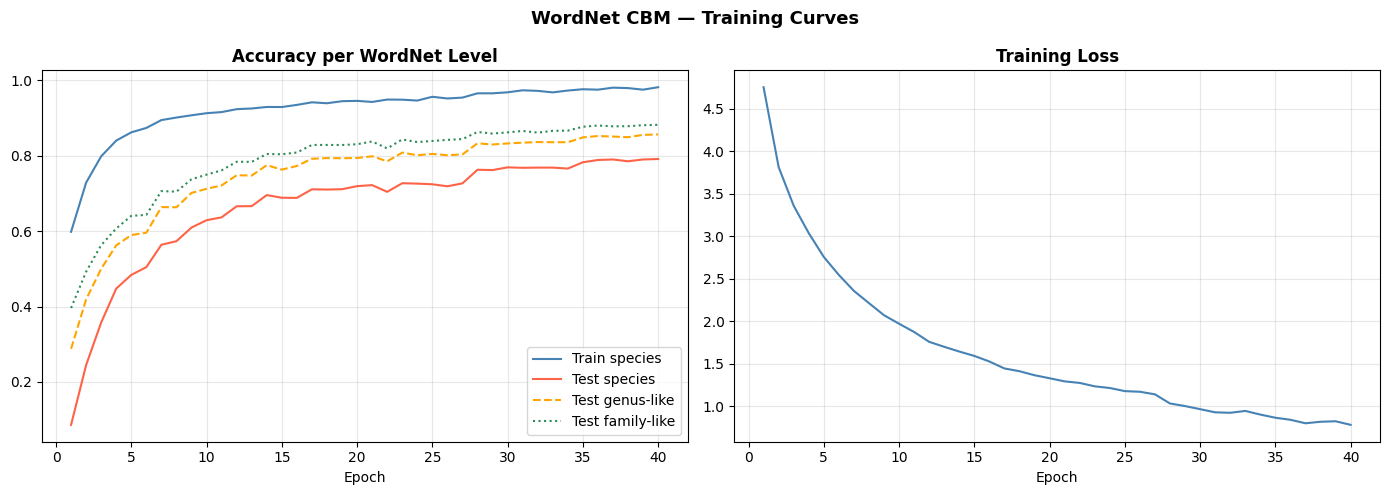

In [15]:
epochs=[r['epoch'] for r in history]; tr_sp=[r['train_sp_acc'] for r in history]; te_sp=[r['test_sp_acc'] for r in history]; te_gen=[r['test_gen_acc'] for r in history]; te_fam=[r['test_fam_acc'] for r in history]; tr_loss=[r['train_loss'] for r in history]
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(epochs,tr_sp,label='Train species',color='steelblue'); axes[0].plot(epochs,te_sp,label='Test species',color='tomato'); axes[0].plot(epochs,te_gen,label='Test genus-like',color='orange',linestyle='--'); axes[0].plot(epochs,te_fam,label='Test family-like',color='seagreen',linestyle=':')
axes[0].set_title('Accuracy per WordNet Level',fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs,tr_loss,color='steelblue'); axes[1].set_title('Training Loss',fontweight='bold'); axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)
plt.suptitle('WordNet CBM — Training Curves', fontsize=13, fontweight='bold'); plt.tight_layout(); plt.savefig(SAVE_DIR / 'wordnet_cbm_curves.png', dpi=150); plt.show()

In [23]:
state = torch.load(CKPT_PATH, map_location=device)
missing, unexpected = model.load_state_dict(state, strict=False)
if missing or unexpected:
    print('Missing keys:', missing); print('Unexpected keys:', unexpected)
    raise RuntimeError('Checkpoint does not exactly match this WordNetCBM definition.')
final = evaluate(model, test_loader, mode='greedy')
print('='*65); print('WORDNET CBM — Final Test Results (greedy inference)'); print('='*65)
print(f'  Species Top-1 accuracy : {final["species_acc"]:.4f} ({final["species_acc"]*100:.2f}%)')
print(f'  Genus-like accuracy    : {final["genus_acc"]:.4f} ({final["genus_acc"]*100:.2f}%)')
print(f'  Family-like accuracy   : {final["family_acc"]:.4f} ({final["family_acc"]*100:.2f}%)')
beam_results = {}
if RUN_BEAM_SEARCH:
    print('\nBeam-search inference diagnostics')
    for bw in BEAM_WIDTHS:
        res = evaluate(model, test_loader, mode='beam', beam_width=bw); beam_results[bw] = res
        print(f'  Beam-{bw}: species={res["species_acc"]:.4f}, genus-like={res["genus_acc"]:.4f}, family-like={res["family_acc"]:.4f}')
oracle_routing = evaluate_oracle_routing(model, test_loader)
print('\nOracle-routing diagnostics (not deployable inference)')
for k,v in oracle_routing.items(): print(f'  {k}: {v:.4f}')
local_concept_quality = evaluate_local_concept_quality(model, test_loader)
print('\nLocal concept-head quality')
display(local_concept_quality)
local_concept_quality.to_csv(SAVE_DIR / 'wordnet_local_concept_quality.csv', index=False)

WORDNET CBM — Final Test Results (greedy inference)
  Species Top-1 accuracy : 0.7910 (79.10%)
  Genus-like accuracy    : 0.8561 (85.61%)
  Family-like accuracy   : 0.8816 (88.16%)

Beam-search inference diagnostics


  Beam-1: species=0.7910, genus-like=0.8561, family-like=0.8816


  Beam-3: species=0.8000, genus-like=0.8626, family-like=0.8864


  Beam-5: species=0.8003, genus-like=0.8630, family-like=0.8868



Oracle-routing diagnostics (not deployable inference)
  greedy_species_acc: 0.7910
  oracle_family_genus_acc: 0.9625
  oracle_family_species_acc: 0.8863
  oracle_family_genus_species_acc: 0.9182



Local concept-head quality


,level,accuracy,macro_like_f1,balanced_accuracy,precision,recall,n_entries
0,root,0.646880,0.430804,0.620676,0.345717,0.571448,463520
1,family,0.694860,0.429113,0.636178,0.359028,0.533197,289700
2,genus,0.707421,0.458379,0.643865,0.407846,0.523206,173820


Mistake Severity — Greedy
  Mean tree distance      : 0.941
  Correct       (dist=0)  : 4583 (79.1%)
  Same genus    (dist=2)  :  377 (6.5%)
  Same family   (dist=4)  :  153 (2.6%)
  Diff family   (dist=6)  :  681 (11.8%)
  Same-genus mistake rate among wrong  : 31.1%
  Same-family mistake rate among wrong : 43.6%
Mistake Severity — Beam-1
  Mean tree distance      : 0.941
  Correct       (dist=0)  : 4583 (79.1%)
  Same genus    (dist=2)  :  377 (6.5%)
  Same family   (dist=4)  :  153 (2.6%)
  Diff family   (dist=6)  :  681 (11.8%)
  Same-genus mistake rate among wrong  : 31.1%
  Same-family mistake rate among wrong : 43.6%
Mistake Severity — Beam-3
  Mean tree distance      : 0.900
  Correct       (dist=0)  : 4635 (80.0%)
  Same genus    (dist=2)  :  363 (6.3%)
  Same family   (dist=4)  :  143 (2.5%)
  Diff family   (dist=6)  :  653 (11.3%)
  Same-genus mistake rate among wrong  : 31.3%
  Same-family mistake rate among wrong : 43.5%


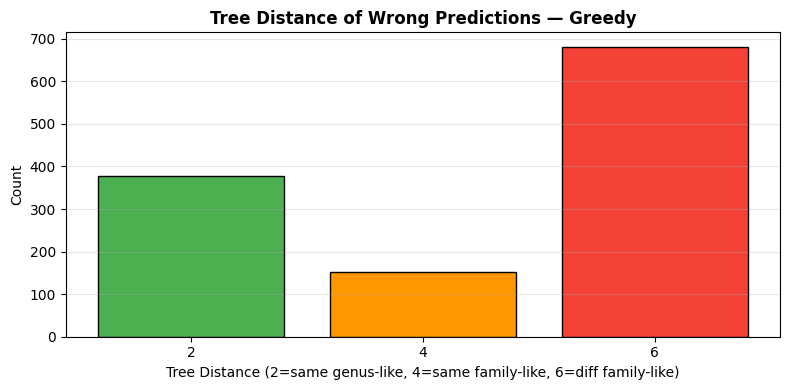

In [17]:
def tree_distance(pred_sp, true_sp):
    if pred_sp == true_sp: return 0
    if species_to_genus.get(pred_sp+1) == species_to_genus.get(true_sp+1): return 2
    if species_to_family.get(pred_sp+1) == species_to_family.get(true_sp+1): return 4
    return 6

def mistake_severity_report(result_dict, title='Greedy'):
    distances = np.array([tree_distance(p,t) for p,t in zip(result_dict['pred_sp'], result_dict['true_sp'])])
    wrong = np.array(result_dict['pred_sp']) != np.array(result_dict['true_sp'])
    if wrong.any():
        same_genus_rate = (np.array(result_dict['pred_gen'])[wrong] == np.array(result_dict['true_gen'])[wrong]).mean()
        same_family_rate = (np.array(result_dict['pred_fam'])[wrong] == np.array(result_dict['true_fam'])[wrong]).mean()
    else:
        same_genus_rate = np.nan; same_family_rate = np.nan
    print(f'Mistake Severity — {title}')
    print(f'  Mean tree distance      : {distances.mean():.3f}')
    print(f'  Correct       (dist=0)  : {(distances==0).sum():4d} ({(distances==0).mean():.1%})')
    print(f'  Same genus    (dist=2)  : {(distances==2).sum():4d} ({(distances==2).mean():.1%})')
    print(f'  Same family   (dist=4)  : {(distances==4).sum():4d} ({(distances==4).mean():.1%})')
    print(f'  Diff family   (dist=6)  : {(distances==6).sum():4d} ({(distances==6).mean():.1%})')
    print(f'  Same-genus mistake rate among wrong  : {same_genus_rate:.1%}')
    print(f'  Same-family mistake rate among wrong : {same_family_rate:.1%}')
    return distances, same_genus_rate, same_family_rate

distances, same_genus_rate, same_family_rate = mistake_severity_report(final, 'Greedy')
beam_severity = {}
for bw,res in beam_results.items():
    d,sgr,sfr = mistake_severity_report(res, f'Beam-{bw}')
    beam_severity[bw] = {'mean_tree_distance':float(d.mean()), 'same_genus_mistake_rate':float(sgr), 'same_family_mistake_rate':float(sfr)}
fig, ax = plt.subplots(figsize=(8,4)); wrong_dist = distances[distances > 0]
if len(wrong_dist) > 0:
    vals,cnts=np.unique(wrong_dist, return_counts=True); colors={2:'#4CAF50',4:'#FF9800',6:'#F44336'}
    ax.bar([str(int(v)) for v in vals], cnts, color=[colors.get(int(v),'gray') for v in vals], edgecolor='black')
ax.set_title('Tree Distance of Wrong Predictions — Greedy', fontweight='bold'); ax.set_xlabel('Tree Distance (2=same genus-like, 4=same family-like, 6=diff family-like)'); ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(SAVE_DIR / 'wordnet_cbm_tree_distance.png', dpi=150); plt.show()

Hierarchical Explanations (root -> family-like -> genus-like -> species)


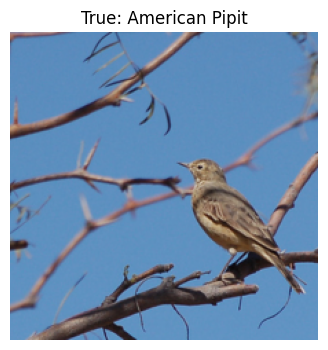

[XX] Predicted: Mockingbird | True: American Pipit
  Root   -> oscine
    concepts: has_back_color::brown (score=0.91, GT=0) | has_nape_color::grey (score=0.90, GT=1) | has_shape::perching-like (score=0.89, GT=1) | has_eye_color::black (score=0.88, GT=1) | has_primary_color::grey (score=0.87, GT=1)
  Family -> mockingbird
    concepts: has_upperparts_color::brown (score=0.97, GT=0) | has_underparts_color::yellow (score=0.96, GT=0) | has_bill_length::about_the_same_as_head (score=0.93, GT=1) | has_breast_color::yellow (score=0.92, GT=0) | has_bill_shape::all-purpose (score=0.87, GT=1)
  Genus  -> Mockingbird
    concepts: has_bill_shape::all-purpose (score=0.75, GT=1) | has_wing_color::brown (score=0.49, GT=0) | has_wing_color::black (score=0.43, GT=0) | has_upperparts_color::grey (score=0.38, GT=1) | has_wing_color::grey (score=0.34, GT=1)



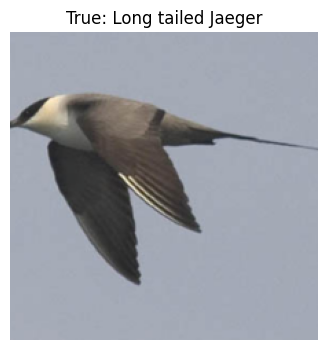

[OK] True: Long tailed Jaeger
  Root   -> coastal diving bird
    concepts: has_throat_color::white (score=0.99, GT=1) | has_upperparts_color::brown (score=0.99, GT=1) | has_nape_color::white (score=0.97, GT=0) | has_head_pattern::eyebrow (score=0.96, GT=0) | has_nape_color::brown (score=0.95, GT=0)
  Family -> jaeger
    concepts: has_wing_color::black (score=0.41, GT=0) | has_bill_shape::hooked_seabird (score=0.40, GT=0) | has_upperparts_color::black (score=0.39, GT=0) | has_upperparts_color::grey (score=0.35, GT=0) | has_wing_color::grey (score=0.34, GT=0)
  Genus  -> Long tailed Jaeger
    concepts: has_breast_pattern::solid (score=0.81, GT=1) | has_bill_color::black (score=0.75, GT=1) | has_throat_color::white (score=0.69, GT=1) | has_back_pattern::solid (score=0.68, GT=1) | has_size::medium_(9_-_16_in) (score=0.67, GT=0)



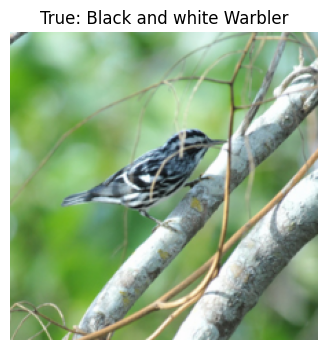

[OK] True: Black and white Warbler
  Root   -> oscine
    concepts: has_eye_color::black (score=0.93, GT=0) | has_bill_shape::all-purpose (score=0.83, GT=1) | has_bill_length::shorter_than_head (score=0.81, GT=1) | has_wing_color::black (score=0.80, GT=1) | has_shape::perching-like (score=0.80, GT=1)
  Family -> warbler
    concepts: has_forehead_color::black (score=0.91, GT=1) | has_bill_shape::all-purpose (score=0.91, GT=1) | has_underparts_color::grey (score=0.88, GT=1) | has_breast_color::grey (score=0.85, GT=0) | has_wing_color::grey (score=0.84, GT=0)
  Genus  -> Black and white Warbler
    concepts: has_crown_color::black (score=0.99, GT=1) | has_forehead_color::black (score=0.97, GT=1) | has_nape_color::white (score=0.96, GT=0) | has_nape_color::yellow (score=0.95, GT=0) | has_upperparts_color::black (score=0.95, GT=1)



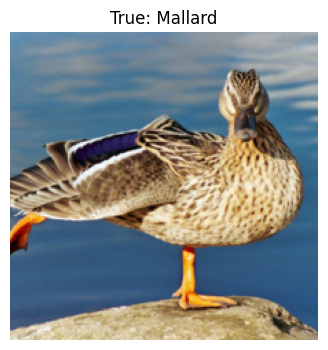

[XX] Predicted: Slaty backed Gull | True: Mallard
  Root   -> larid
    concepts: has_upperparts_color::white (score=0.97, GT=0) | has_wing_color::white (score=0.96, GT=0) | has_forehead_color::black (score=0.87, GT=0) | has_forehead_color::white (score=0.86, GT=0) | has_nape_color::white (score=0.83, GT=0)
  Family -> gull
    concepts: has_forehead_color::white (score=0.71, GT=0) | has_breast_pattern::solid (score=0.68, GT=0) | has_wing_color::grey (score=0.67, GT=0) | has_crown_color::white (score=0.59, GT=0) | has_bill_shape::hooked_seabird (score=0.58, GT=0)
  Genus  -> Slaty backed Gull
    concepts: has_bill_color::yellow (score=0.90, GT=0) | has_upperparts_color::white (score=0.83, GT=0) | has_upperparts_color::black (score=0.82, GT=0) | has_belly_color::white (score=0.81, GT=0) | has_crown_color::grey (score=0.80, GT=0)



In [18]:
@torch.no_grad()
def top_local_concepts(concept_scores, global_mask, full_gt_concepts=None, k=5):
    vals = concept_scores.detach().cpu().numpy(); order = np.argsort(vals)[::-1][:k]; rows=[]
    for local_idx in order:
        global_idx = int(global_mask[local_idx]); name = attrs_df.iloc[global_idx]['attr_name']
        row = {'concept': name, 'score': float(vals[local_idx]), 'global_idx': global_idx}
        if full_gt_concepts is not None: row['gt'] = int(full_gt_concepts[global_idx].item())
        rows.append(row)
    return rows
@torch.no_grad()
def explain_sample(model, image_tensor, concept_vector, top_k=5):
    feats = model.features(image_tensor.unsqueeze(0).to(device)); concept_vector = concept_vector.to(device)
    fam_logits, root_c = model.root_head(feats); pred_fid = int(fam_logits.argmax(dim=1).item()); root_rows = top_local_concepts(root_c[0], root_concept_mask, concept_vector, top_k)
    g_log, fam_c = model.family_heads[str(pred_fid)](feats); gids_in_fam = family_to_genera_map[pred_fid]; pred_gid = gids_in_fam[int(g_log.argmax(dim=1).item())]; fam_rows = top_local_concepts(fam_c[0], family_concept_masks[pred_fid], concept_vector, top_k)
    s_log, gen_c = model.genus_heads[str(pred_gid)](feats); sp_in_gen = genus_to_species_map[pred_gid]; pred_sid = sp_in_gen[int(s_log.argmax(dim=1).item())]; gen_rows = top_local_concepts(gen_c[0], genus_concept_masks[pred_gid], concept_vector, top_k)
    pred_sp_name = classes_df[classes_df['class_id'] == pred_sid + 1]['class_name'].iloc[0].split('.',1)[-1].replace('_',' ')
    return {'family':all_families[pred_fid], 'root_concepts':root_rows, 'genus':all_genera[pred_gid], 'fam_concepts':fam_rows, 'species':pred_sp_name, 'gen_concepts':gen_rows}
def format_concept_rows(rows):
    if not rows: return '(none)'
    chunks=[]
    for r in rows:
        gt = f", GT={r['gt']}" if 'gt' in r else ''
        chunks.append(f"{r['concept']} (score={r['score']:.2f}{gt})")
    return ' | '.join(chunks)
def denormalize_image(tensor):
    mean=torch.tensor(IMAGENET_MEAN).view(3,1,1); std=torch.tensor(IMAGENET_STD).view(3,1,1); tensor=tensor.cpu()*std+mean; tensor=torch.clamp(tensor,0,1); return tensor.permute(1,2,0).numpy()

test_ds_noaug = CUBTaxonomyDataset(test_df, concept_matrix, CUB_DIR, species_to_genus, species_to_family, test_transform)
model.eval(); all_pred_sp=final['pred_sp']; all_true_sp=final['true_sp']
correct_indices=[i for i,(p,t) in enumerate(zip(all_pred_sp, all_true_sp)) if p==t]; incorrect_indices=[i for i,(p,t) in enumerate(zip(all_pred_sp, all_true_sp)) if p!=t]
np.random.seed(0); selected=[]
if len(correct_indices)>0: selected.extend(np.random.choice(correct_indices, min(2,len(correct_indices)), replace=False).tolist())
if len(incorrect_indices)>0: selected.extend(np.random.choice(incorrect_indices, min(2,len(incorrect_indices)), replace=False).tolist())
np.random.shuffle(selected)
print('Hierarchical Explanations (root -> family-like -> genus-like -> species)'); print('='*90)
for idx in selected:
    img, concepts, true_sp, _, _ = test_ds_noaug[int(idx)]
    true_name = classes_df[classes_df['class_id'] == true_sp+1]['class_name'].iloc[0].split('.',1)[-1].replace('_',' ')
    plt.figure(figsize=(4,4)); plt.imshow(denormalize_image(img)); plt.title(f'True: {true_name}'); plt.axis('off'); plt.show()
    expl = explain_sample(model, img, concepts, top_k=5); mark = 'OK' if expl['species'].lower() == true_name.lower() else 'XX'
    if mark == 'OK': print(f'[{mark}] True: {true_name}')
    else: print(f"[{mark}] Predicted: {expl['species']} | True: {true_name}")
    print(f'  Root   -> {expl["family"]}'); print(f'    concepts: {format_concept_rows(expl["root_concepts"])}')
    print(f'  Family -> {expl["genus"]}'); print(f'    concepts: {format_concept_rows(expl["fam_concepts"])}')
    print(f'  Genus  -> {expl["species"]}'); print(f'    concepts: {format_concept_rows(expl["gen_concepts"])}')
    print()

In [19]:
results = {
    'model': 'wordnet_cbm',
    'model_description': 'hierarchical classifier with local concept bottleneck heads',
    'backbone': 'resnet50_finetuned',
    'taxonomy_source': 'wordnet',
    'taxonomy_caveat': 'family/genus are WordNet-derived semantic/taxonomic levels, not guaranteed strict biological taxonomy',
    'n_families': int(N_FAMILIES), 'n_genera': int(N_GENERA), 'n_species': int(N_CLASSES),
    'greedy': {'species_accuracy': float(final['species_acc']), 'genus_accuracy': float(final['genus_acc']), 'family_accuracy': float(final['family_acc']), 'mean_tree_distance': float(distances.mean()), 'same_genus_mistake_rate': None if np.isnan(same_genus_rate) else float(same_genus_rate), 'same_family_mistake_rate': None if np.isnan(same_family_rate) else float(same_family_rate)},
    'beam': {str(bw): {'species_accuracy': float(res['species_acc']), 'genus_accuracy': float(res['genus_acc']), 'family_accuracy': float(res['family_acc']), **beam_severity.get(bw,{})} for bw,res in beam_results.items()},
    'oracle_routing_diagnostics': {k: float(v) for k,v in oracle_routing.items()},
    'local_concept_quality': local_concept_quality.to_dict(orient='records'),
}
out_path = SAVE_DIR / 'wordnet_cbm_results.json'
with open(out_path, 'w') as f: json.dump(results, f, indent=2)
print(f'Saved: {out_path}'); print(json.dumps(results, indent=2))

Saved: /content/processed/wordnet_cbm_results.json
{
  "model": "wordnet_cbm",
  "model_description": "hierarchical classifier with local concept bottleneck heads",
  "backbone": "resnet50_finetuned",
  "taxonomy_source": "wordnet",
  "taxonomy_caveat": "family/genus are WordNet-derived semantic/taxonomic levels, not guaranteed strict biological taxonomy",
  "n_families": 62,
  "n_genera": 109,
  "n_species": 200,
  "greedy": {
    "species_accuracy": 0.7909906800138073,
    "genus_accuracy": 0.8560579910251985,
    "family_accuracy": 0.8816016568864342,
    "mean_tree_distance": 0.9409734207801174,
    "same_genus_mistake_rate": 0.31131296449215523,
    "same_family_mistake_rate": 0.4360033030553262
  },
  "beam": {
    "1": {
      "species_accuracy": 0.7909906800138073,
      "genus_accuracy": 0.8560579910251985,
      "family_accuracy": 0.8816016568864342,
      "mean_tree_distance": 0.9409734207801174,
      "same_genus_mistake_rate": 0.31131296449215523,
      "same_family_mistak

In [21]:
PRINT_FULL_TAXONOMY = True
if PRINT_FULL_TAXONOMY:
    print('--- Hierarchical WordNet Taxonomy ---')
    for fid, family_name in enumerate(all_families):
        print(f'\nFamily-like group: {family_name} (ID: {fid})')
        for gid in family_to_genera_map.get(fid, []):
            print(f'  Genus-like group: {all_genera[gid]} (ID: {gid})')
            species_names=[]
            for sp_idx in genus_to_species_map.get(gid, []):
                class_id=sp_idx+1; species_name=classes_df[classes_df['class_id']==class_id]['class_name'].iloc[0]
                species_names.append(species_name.split('.',1)[-1].replace('_',' '))
            print(f"    Species: {', '.join(species_names)}")
else:
    print('Full taxonomy print skipped. Set PRINT_FULL_TAXONOMY=True to display it.')

--- Hierarchical WordNet Taxonomy ---

Family-like group: New World blackbird (ID: 0)
  Genus-like group: cowbird (ID: 35)
    Species: Bronzed Cowbird, Shiny Cowbird
  Genus-like group: rusty blackbird (ID: 83)
    Species: Rusty Blackbird

Family-like group: New World flycatcher (ID: 1)
  Genus-like group: kingbird (ID: 61)
    Species: Tropical Kingbird

Family-like group: New World jay (ID: 2)
  Genus-like group: blue jay (ID: 21)
    Species: Blue Jay

Family-like group: New World oriole (ID: 3)
  Genus-like group: New World blackbird (ID: 8)
    Species: Brewer Blackbird, Red winged Blackbird, Yellow headed Blackbird
  Genus-like group: bobolink (ID: 22)
    Species: Bobolink
  Genus-like group: meadowlark (ID: 68)
    Species: Horned Lark
  Genus-like group: orchard oriole (ID: 74)
    Species: Orchard Oriole

Family-like group: New World sparrow (ID: 4)
  Genus-like group: chipping sparrow (ID: 31)
    Species: Chipping Sparrow
  Genus-like group: field sparrow (ID: 40)
    Spe